# Non-football Fatalities 

[insert introduction here]

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

import warnings
warnings.simplefilter('ignore')

In [17]:
metadata = pd.read_csv('data/shootings_metadata_fields.csv')
calls = pd.read_csv('data/hex_911_calls.csv')
calls_json = gpd.read_file('data/hex_911_calls.geojson')
ppd_dist_gdf = gpd.read_file('data/Boundaries_District.geojson')
hexes = gpd.read_file('data/h3_hex_grid_r8.geojson')

In [4]:
shootings = pd.read_csv('data/shootings.csv')
shootings.head()

,the_geom,the_geom_webmercator,objectid,year,dc_key,code,date_,time,race,sex,...,location,latino,point_x,point_y,dist,inside,outside,fatal,lat,lng
0,0101000020E61000003CDB07ACFEC752C08841D6A92B03...,0101000020110F0000BA1043EEDCE65FC1DE02479C6993...,1,2021,2.021250e+11,100.0,2021-04-18,06:16:00,W,F,...,4800 BLOCK N HOWARD ST,0.0,-75.124919,40.024770,25.0,1.0,0.0,1.0,40.024770,-75.124919
1,0101000020E61000008CD8ADB931CA52C0C8B91833E402...,0101000020110F000053465B5599EA5FC1B9C82C5A1A93...,2,2021,2.021390e+11,100.0,2021-04-07,14:43:00,B,M,...,2000 BLOCK WINDRIM AVE,0.0,-75.159285,40.022589,39.0,0.0,1.0,1.0,40.022589,-75.159285
2,0101000020E61000008CD8ADB931CA52C0C8B91833E402...,0101000020110F000053465B5599EA5FC1B9C82C5A1A93...,3,2021,2.021390e+11,100.0,2021-04-07,14:43:00,B,M,...,2000 BLOCK WINDRIM AVE,0.0,-75.159285,40.022589,39.0,0.0,1.0,0.0,40.022589,-75.159285
3,0101000020E6100000DC861B6728C852C0800655890300...,0101000020110F000063028BD023E75FC13C7C9D7DE98F...,4,2023,2.023250e+11,100.0,2023-02-16,04:55:00,W,M,...,100 BLOCK E WESTMORLAND ST,1.0,-75.127466,40.000108,25.0,0.0,1.0,1.0,40.000108,-75.127466
4,0101000020E6100000DC861B6728C852C0800655890300...,0101000020110F000063028BD023E75FC13C7C9D7DE98F...,5,2023,2.023390e+11,400.0,2023-02-16,04:55:00,W,F,...,100 BLOCK E WESTMORLAND ST,1.0,-75.127466,40.000108,25.0,0.0,1.0,0.0,40.000108,-75.127466


In [5]:
shootings.columns
len(shootings)
shootings['year'].max()

np.int64(2026)

Each row of the Philly Shootings Dataset the dataset seems to correspond to an individual shooting, including location data, the date and time, demographic data about the shooter, and whether the shooting was fatal.

In addition to this dataset, Open Data Philly also has a dataset of 911 calls in Philadelphia which we can use to contextualize the shooting data. This includes all emergency calls made to the Philadelphia Fire and Police Departments in 2024. 

In [6]:
calls.head()

,total_calls,high_priority,medium_priority,low_priority,gridid,objectid,Shape__Area,Shape__Length
0,2637,155,668,1814,882a134001fffff,1,1.252007e+06,4168.437714
1,290,26,72,192,882a134003fffff,2,1.251530e+06,4167.647874
2,2107,148,723,1236,882a134005fffff,3,1.252150e+06,4168.674157
3,563,4,43,516,882a134007fffff,4,1.251674e+06,4167.886020
4,1517,55,332,1130,882a134009fffff,5,1.252337e+06,4168.983888


In [7]:
calls.columns

Index(['total_calls', 'high_priority', 'medium_priority', 'low_priority',
       'gridid', 'objectid', 'Shape__Area', 'Shape__Length'],
      dtype='str')

This dataset seems to be organized into hexdemcimal shapes, with a particular shape area and a total number of calls within the area. 


We know from other research that crimes are often less likely to be reported in areas with higher crime. While residents of high-poverty neighborhoods often experience higher rates of victimization, they also report crimes at lower rates due to a combination of mistrust in law enforcement, fear of retaliation, and cultural factors. 

The combination of these two datasets allows us to investigate this relationship in Philadelphia. Is there a conection between the number of emergency calls made to an area and the number of shootings that happen in that area? Does this change for high, medium, and low priority calls? What about for different racial and demographic groups experiencing gun violence? What does this tell us about the relationship between gun violence and different crime reporting patterns? 

## Is there a conection between the number of emergency calls made to an area and the number of shootings that happen in that area? 

In [8]:
# first determine how many shootings there were in 2024
filt = shootings['year'] == 2024
shootings = shootings[filt]
len(shootings)


1112

In [9]:
len(shootings[shootings['fatal']==1])
shootings.info()

<class 'pandas.DataFrame'>
Index: 1112 entries, 18 to 17513
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   the_geom              1112 non-null   str    
 1   the_geom_webmercator  1108 non-null   str    
 2   objectid              1112 non-null   int64  
 3   year                  1112 non-null   int64  
 4   dc_key                1112 non-null   float64
 5   code                  1080 non-null   float64
 6   date_                 1112 non-null   str    
 7   time                  1083 non-null   str    
 8   race                  1083 non-null   str    
 9   sex                   1096 non-null   str    
 10  age                   1077 non-null   float64
 11  wound                 1082 non-null   str    
 12  officer_involved      1112 non-null   str    
 13  offender_injured      1111 non-null   str    
 14  offender_deceased     1112 non-null   str    
 15  location              1112 non-null

There are 1,112 entries for the shootings dataset in 2024, and 228 of those shootings were fatal. 

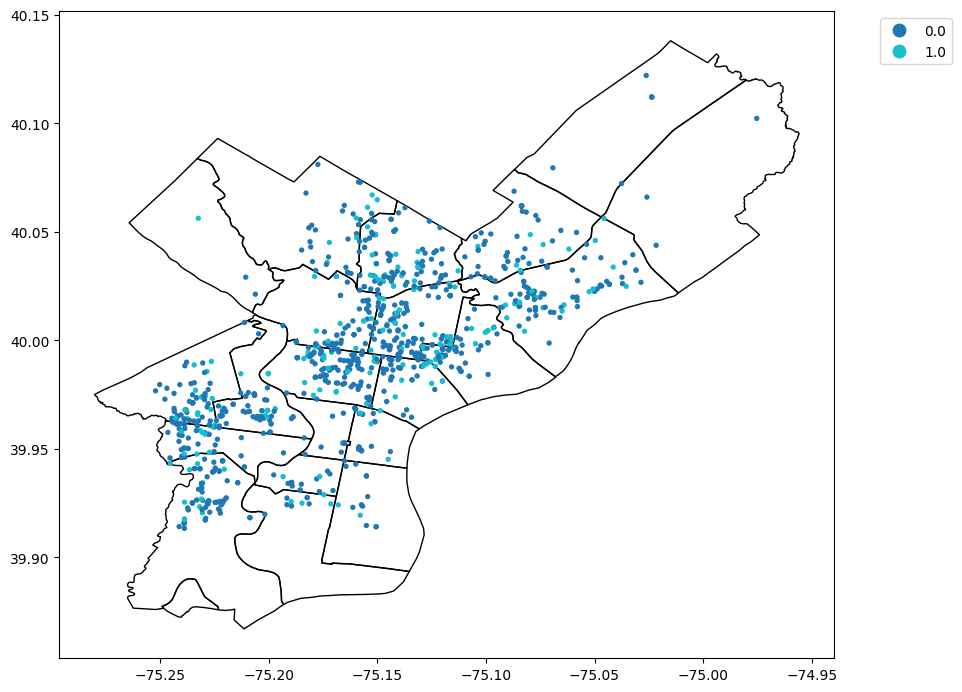

In [10]:
#plotting the shootings data based on 
geom= gpd.points_from_xy(shootings['point_x'],
                  shootings['point_y'])
shootings_gdf= gpd.GeoDataFrame(shootings, geometry=geom)
base = ppd_dist_gdf.plot(color = 'none', edgecolor='black', figsize = (10,10))

shootings_gdf.plot(ax=base, 
                          markersize=8, 
                          column='fatal', 
                          categorical=True, 
                          legend=True,
                          legend_kwds={'bbox_to_anchor': (1.05, 1), 'loc': 'upper left'})

plt.show()

The plot demonstrates that shootings in Philadelphia seem to be concentrated in North and West Philadelphia. Theree are significant numbers of fatal shootings by Kensington, and concentrated around Leigh Avenue in North Philly, as well as in far West Philadelphia, concentrated along Market and 60th street. It is notable that these neighborhoods tend to be significantly lower socioeconomic status than center city, and the farthest North and East suburbs of the city. 

This graph is useful at establishing a baseline for where gun violence is most likely to occur in Philadelphia, so that we can better understand the connection between geography, violence, and emergency call data. 

In [11]:
#plotting the emergency call data: 
calls_json['centX']= calls_json.centroid.x
calls_json['centY']= calls_json.centroid.y

calls_json.head()

,total_calls,high_priority,medium_priority,low_priority,gridid,objectid,Shape__Area,Shape__Length,geometry,centX,centY
0,2637,155,668,1814,882a134001fffff,1,1.252007e+06,4168.437714,"POLYGON ((-74.99245 40.05098, -74.98803 40.047...",-74.994298,40.046543
1,290,26,72,192,882a134003fffff,2,1.251530e+06,4167.647874,"POLYGON ((-74.98988 40.04321, -74.98545 40.039...",-74.991719,40.038768
2,2107,148,723,1236,882a134005fffff,3,1.252150e+06,4168.674157,"POLYGON ((-75.00315 40.05322, -74.99872 40.049...",-75.004988,40.048779
3,563,4,43,516,882a134007fffff,4,1.251674e+06,4167.886020,"POLYGON ((-75.00056 40.04544, -74.99614 40.042...",-75.002406,40.041004
4,1517,55,332,1130,882a134009fffff,5,1.252337e+06,4168.983888,"POLYGON ((-74.98434 40.05652, -74.97992 40.053...",-74.986188,40.052082


In [16]:
calls['objectid'].max() #number of hexagons plotted

np.int64(579)

In [ ]:
#calls_json.plot(color='white', edgecolor='gray', figsize=(10,10))

# calls_json.apply(lambda r: plt.text(r['centX'], r['centY'], r['objectid']),axis=1) #this is pretty gross when plotted, so omitted for clarity's sake. 
# plt.show()
fig, ax = plt.subplots(figsize = (10,10))

calls_json.plot(edgecolor='gray', column='total_calls', ax = ax, 
                         legend=True, cmap='Oranges',
               legend_kwds= { 'shrink': 0.5}) #used claude to understand how to shrink the legend and add a label
ax.set_title("Calls to 911 in Philadelphia (2024)", fontsize = 16)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

plt.show()

Although this graph is somewhat helpful in allowing us to look at the concentration of 911 cals across Philadelphia, demonstrating that there are clearly regions of the city which are much more likely to experience 911 calls, it is difficult to contextualize the location of the shootings without understanding how the hexagons align with different district boundaries in Philadelphia. 

In that case, it might be helpful to overlay 911 calls and district data so we can undertsand where these calls are made most frequently. 

In [ ]:
fig, ax = plt.subplots(figsize = (10,10))

calls_json.plot(edgecolor='gray', column='total_calls', ax = ax, 
                         legend=True, cmap='Oranges',
               legend_kwds= { 'shrink': 0.5}) #used claude to understand how to shrink the legend and add a label

ppd_dist_gdf.plot(ax=ax, color = 'none', edgecolor='black')
ax.set_title("Calls to 911 in Philadelphia (2024)", fontsize = 16)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

plt.show()

From this graph, we can better see that emergency calls seem to be concentrated in North and West Philadelphia, much like the shooting dataset however the graph also seems to have a high number of calls from the neighborhoods by center city. The suburban neighborhoods in the far north of the city seem to have significantly lower volumes of emergency calls. 

This is a strange finding based on the shooting data visualization. In this earlier graph, we noticed that calls were more likely to be concentrated further North, and there were very few datapoints for center city. It's possible that there is a disconnect between the amount of emergency calls that an area receives, and the amount of gun violence in that area. We should be cautious not to conclude that just because an area is more likely to make calls to 911, they are more likely to be experiencing violent crime. 

We might explain this by the fact that 911 calls capture a variety of events, not just violent crimes. Therefore we shouldn't conflate calls that are made about house fires, or medical scares, for example, and calls made which would correspond to a shooting. 

## Does this change for high, medium, and low priority calls? 

One way of examining this difference is to look at the differences in geographic concentration of high, medium, and low priority calls in the emergency call dataset. 

In [ ]:
fig, axes = plt.subplots(1, 3, figsize = (24,8)) #changing the number of subplots
    #also want to adjust the figure size to accommodate a faceted graph

#asked Claude to help me change the colors of the faceted graph
    #need to make a map with the different colors and corresponding columns: 
panels = [('low_priority', 'Greens'), 
         ('medium_priority', 'YlOrBr'), 
         ('high_priority', 'Reds')]


#need to make a for loop to plot each graph, iterating over the different columns that 
    #correspond to the types of emergency calls that people make. 
for ax, (col, cmap) in zip(axes, panels): #define columns
    calls_json.plot(edgecolor='gray', column=col, ax = ax, 
                         legend=True, cmap=cmap, #need to figure out how to swap these colors
               legend_kwds= {'label': col, 'shrink': 0.5}) #used claude to understand how to shrink the legend and add a label
    ppd_dist_gdf.plot(ax=ax, color = 'none', edgecolor='black')
    ax.set_title("Calls to 911 in Philadelphia (2024)", fontsize = 16)
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)

plt.show()

The graphs above demonstrate that the spatial distribution of emergency calls does change based on the type of call analyzed. Center city still has the most calls in each type of graph (which we might expect based on its location at the intersection of the Broad Street And Market Frankford Lines). However high priority calls are significantly more likely in Northeast Philadelphia, especially at the intersection of the precincts on Leigh Avenue and in Kensington. Given the well known drug-abuse issues in this neighborhood, and high poverty rates in certain concentrated areas, it makes sense that we might see higher numbers of emergency calls. Similarly, we see more high-priority calls stretching across west Philadelphia, with low-priority calls concentrated only in two cells of the graph. 

## Are shootings and emergency calls correlated? 

To determine if this pattern is true beyond image-based analysis, we can look at the correlation betwen shootings and emergency calls if we arrange the shooting data into the same unit of analysis. 

In [22]:
# crash_hex7_gdf = gpd.sjoin(hex_r7, crash_gdf)
#join the shootings dataset and the hexagons
shoot_hex = gpd.sjoin(hexes, shootings_gdf)
shoot_hex.columns #don't know why i get a left and right object id...

Index(['objectid_left', 'grid_id', 'Shape__Area', 'Shape__Length', 'geometry',
       'index_right', 'the_geom', 'the_geom_webmercator', 'objectid_right',
       'year', 'dc_key', 'code', 'date_', 'time', 'race', 'sex', 'age',
       'wound', 'officer_involved', 'offender_injured', 'offender_deceased',
       'location', 'latino', 'point_x', 'point_y', 'dist', 'inside', 'outside',
       'fatal', 'lat', 'lng'],
      dtype='str')

In [ ]:
# crash_cnt_hex7 = crash_hex7_gdf.dissolve(by='objectid', aggfunc='count')
#aggregate the number of shootings into different hexagons (?)
cnt_shoot_hex = shoot_hex.dissolve(by = '')

In [ ]:
# crash_cnt_hex7.plot(column='grid_id', legend=True)#
#plot the results of the shootings by hexagon


In [ ]:
#merge shootings data and 

# Conclusion 

## What does this tell us about the relationship between gun violence and different crime reporting patterns? 